[XGBoost 결과] MAE: 166.87 | Coverage: 82.72% | Width: 692.27


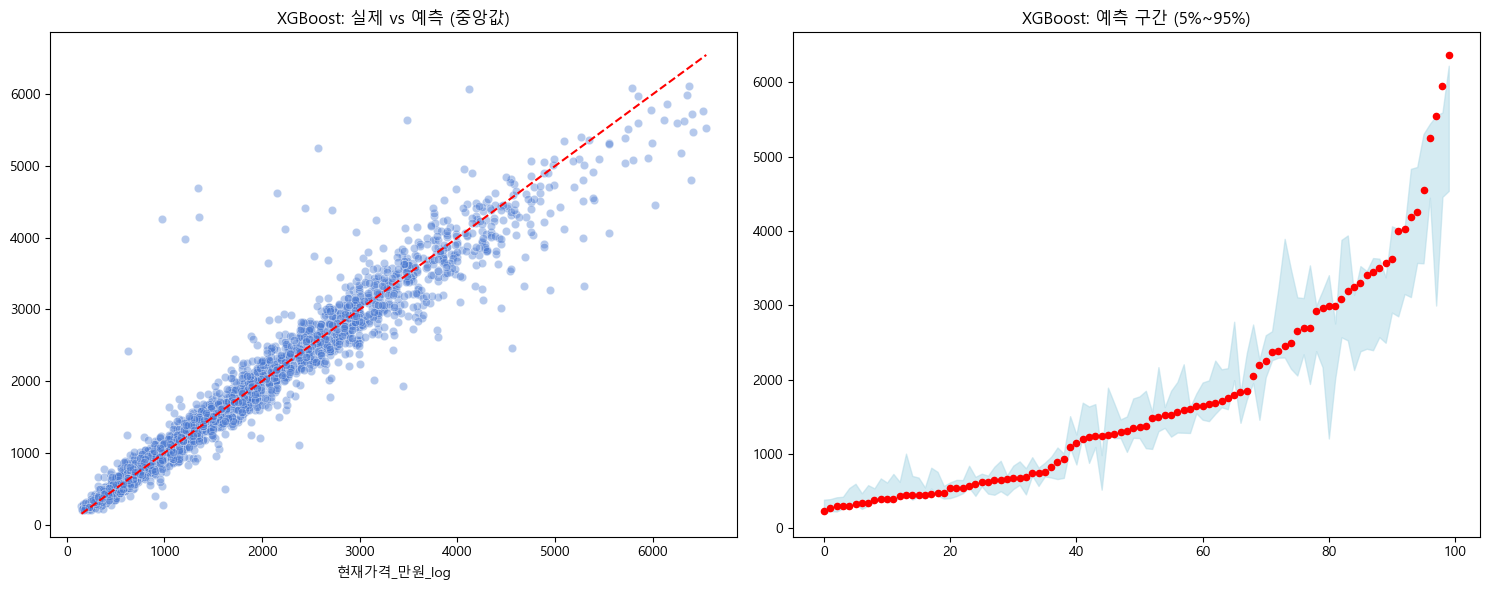

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_pinball_loss
from xgboost import XGBRegressor

# 1. 데이터 로드 및 전처리
df = pd.read_csv('./data/bermuda_data_v1_no_ev.csv')

def remove_outliers_iqr(data, column, multiplier=2.0):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= Q1 - multiplier * IQR) & (data[column] <= Q3 + multiplier * IQR)]

df_clean = remove_outliers_iqr(df, '현재가격_만원')
df_clean = remove_outliers_iqr(df_clean, '주행거리_km')

# 파생 변수 및 인코딩
df_clean['연간_주행거리'] = df_clean['주행거리_km'] / (df_clean['차량연령'] + 1)
df_clean = pd.get_dummies(df_clean, columns=['모델'], drop_first=True)
df_clean = df_clean.drop(columns=['매물ID'])

# 수치형 변수 로그 변환
for col in ['현재가격_만원', '주행거리_km', '배기량_cc', '연간_주행거리', '차량연령']:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

X = df_clean.drop(columns=['현재가격_만원', '현재가격_만원_log', '주행거리_km', '배기량_cc', '연간_주행거리', '차량연령'])
y = df_clean['현재가격_만원_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_test_real = np.expm1(y_test)

# 2. XGBoost 분위수 모델 학습 (0.05, 0.5, 0.95)
quantiles = [0.05, 0.5, 0.95]
models_xgb = {}

for q in quantiles:
    xgb = XGBRegressor(
        objective='reg:quantileerror', 
        quantile_alpha=q, 
        n_estimators=800, 
        learning_rate=0.03, 
        max_depth=8, 
        subsample=0.8, 
        colsample_bytree=0.8, 
        random_state=42
    )
    xgb.fit(X_train, y_train)
    models_xgb[q] = xgb

# 3. 예측 및 지표 계산
preds_xgb = {q: np.expm1(models_xgb[q].predict(X_test)) for q in quantiles}

mae = mean_absolute_error(y_test_real, preds_xgb[0.5])
coverage = np.mean((y_test_real >= preds_xgb[0.05]) & (y_test_real <= preds_xgb[0.95])) * 100
avg_width = np.mean(preds_xgb[0.95] - preds_xgb[0.05])

print(f"[XGBoost 결과] MAE: {mae:.2f} | Coverage: {coverage:.2f}% | Width: {avg_width:.2f}")

# 4. 시각화 (XGBoost 단독)
plt.rc('font', family='Malgun Gothic') # Mac은 'AppleGothic'
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 실제 vs 예측
sns.scatterplot(x=y_test_real, y=preds_xgb[0.5], alpha=0.4, ax=axes[0])
axes[0].plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--')
axes[0].set_title("XGBoost: 실제 vs 예측 (중앙값)")

# 예측 구간 (샘플 100개)
sample_idx = np.random.choice(len(y_test_real), 100, replace=False)
sort_idx = np.argsort(y_test_real.iloc[sample_idx].values)

axes[1].fill_between(range(100), preds_xgb[0.05][sample_idx][sort_idx], 
                     preds_xgb[0.95][sample_idx][sort_idx], color='lightblue', alpha=0.5)
axes[1].scatter(range(100), y_test_real.iloc[sample_idx].values[sort_idx], color='red', s=20)
axes[1].set_title("XGBoost: 예측 구간 (5%~95%)")

plt.tight_layout()
plt.show()

In [16]:
# ... (기존 시각화 코드까지 실행 완료 후) ...

import joblib
import os

# 5. 앱 구동을 위한 모델 및 메타데이터 저장 (.pkl)

# 저장할 디렉토리 생성
save_dir = './models'
os.makedirs(save_dir, exist_ok=True)

# 1) 학습된 XGBoost 분위수 모델 딕셔너리 저장
model_path = os.path.join(save_dir, 'xgb_quantile_models.pkl')
joblib.dump(models_xgb, model_path)

# 2) 학습에 사용된 최종 피처 컬럼명 리스트 저장 (앱에서 입력 데이터 구조 맞출 때 필수)
feature_columns = X.columns.tolist()
features_path = os.path.join(save_dir, 'model_features.pkl')
joblib.dump(feature_columns, features_path)

print(f"✅ 모델 파일 저장 완료: {model_path}")
print(f"✅ 피처 메타데이터 저장 완료: {features_path}")

✅ 모델 파일 저장 완료: ./models\xgb_quantile_models.pkl
✅ 피처 메타데이터 저장 완료: ./models\model_features.pkl
